In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import re

In [3]:
df = pd.read_csv('../data/cars.csv')

In [4]:
df

,manufacturer,model,year,mileage,engine,transmission,drivetrain,fuel_type,mpg,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,seller_name,seller_rating,driver_rating,driver_reviews_num,price_drop,price
0,Acura,ILX Hybrid 1.5L,2013,92945.0,"1.5L I-4 i-VTEC variable valve control, engine...",Automatic,Front-wheel Drive,Gasoline,39-38,Black,Parchment,0.0,0.0,0.0,Iconic Coach,NaN,4.4,12.0,300.0,13988.0
1,Acura,ILX Hybrid 1.5L,2013,47645.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Gray,Ebony,1.0,1.0,1.0,Kars Today,NaN,4.4,12.0,NaN,17995.0
2,Acura,ILX Hybrid 1.5L,2013,53422.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Bellanova White Pearl,Ebony,0.0,1.0,1.0,Weiss Toyota of South County,4.3,4.4,12.0,500.0,17000.0
3,Acura,ILX Hybrid 1.5L,2013,117598.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Polished Metal Metallic,NaN,0.0,1.0,1.0,Apple Tree Acura,NaN,4.4,12.0,675.0,14958.0
4,Acura,ILX Hybrid 1.5L,2013,114865.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,NaN,Ebony,1.0,0.0,1.0,Herb Connolly Chevrolet,3.7,4.4,12.0,300.0,14498.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762086,Volvo,S60 B5 Momentum,2022,22877.0,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,All-wheel Drive,Gasoline,25-33,Bright Silver Metallic,Blond,0.0,1.0,0.0,Volvo Cars Danbury,4.2,4.2,2.0,250.0,34798.0
762087,Volvo,S60 T5,2012,72900.0,250.0HP 2.5L 5 Cylinder Engine Gasoline Fuel,A/T,Front-wheel Drive,Gasoline,NaN,Red,Beige,NaN,NaN,NaN,NaN,NaN,4.5,101.0,NaN,12500.0
762088,Volvo,S60 T5,2014,92000.0,2.5L I5 20V MPFI DOHC Turbo,6-Speed Automatic,Front-wheel Drive,Gasoline,21-30,Ice White,Soft Beige,0.0,0.0,1.0,Dapper Car Sales,NaN,4.8,36.0,300.0,12299.0
762089,Volvo,S60 T5 Platinum,2013,132000.0,2.5L I5 20V MPFI DOHC Turbo,6-Speed Automatic,All-wheel Drive,Gasoline,20-29,Ice White,Off Black,1.0,0.0,0.0,Legend Auto Sales Inc.,4.6,4.7,62.0,1000.0,8995.0


In [4]:
model_counts = df["model"].str.lower().value_counts()
#model_counts = df["model"].value_counts()
model_counts[model_counts > 50]
#model_counts

model
fusion se              3172
sportage lx            2873
corolla le             2836
glc 300 base 4matic    2718
sentra sv              2652
                       ... 
330e 330e                51
supra 2.0                51
patriot limited          51
sl-class 560sl           51
cla 250                  51
Name: count, Length: 2247, dtype: int64

In [5]:
df["year"].isna().value_counts()

year
False    762091
Name: count, dtype: int64

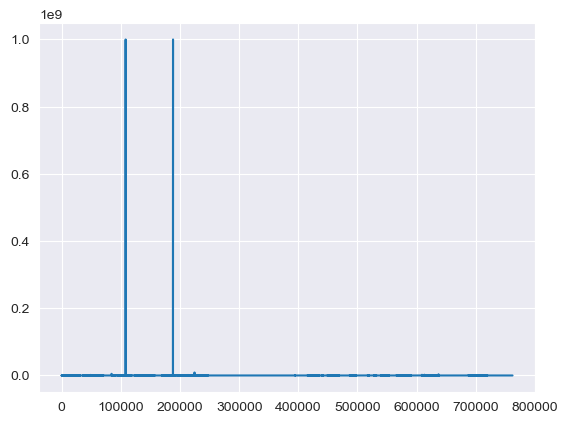

In [6]:
#Рассмотри гистограмму цен
plt.plot(df["price"])

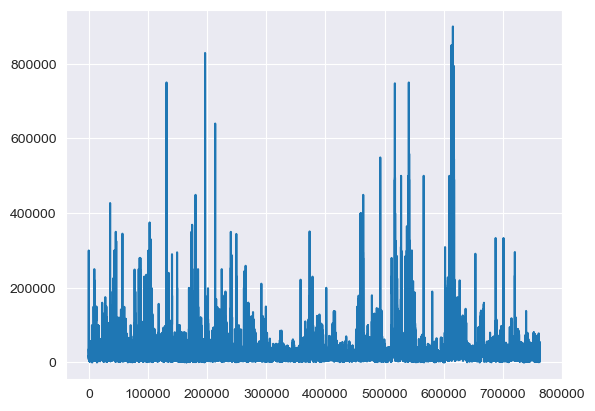

In [7]:
#УБерем явные выбросы
df = df[df["price"] < 1000000]
plt.plot(df["price"])

<Axes: >

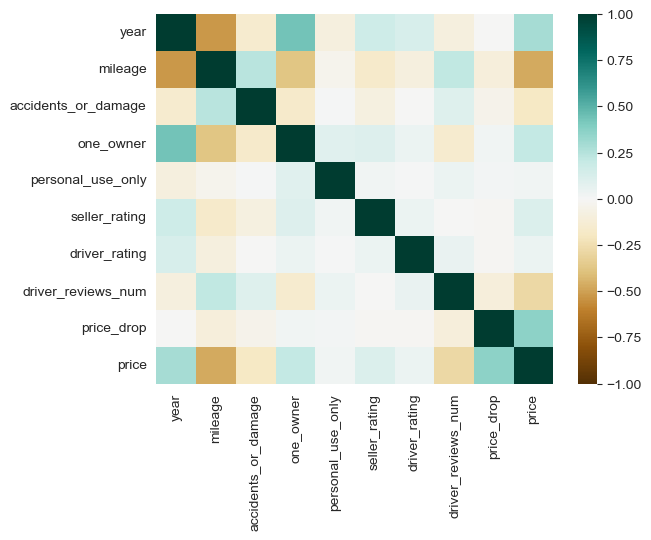

In [23]:
num_cols = df.loc[:, df.dtypes != object].columns

sns.heatmap(
    df[num_cols].corr(),
    vmin=-1,
    vmax=1,
    cmap='BrBG'
)

In [8]:
#рссмотрим среднюю стоимость каждого производителя
#df.groupby("manufacturer").median(numeric_only=True).sort_values("price", ascending=False)["price"]
df.groupby("manufacturer").median(numeric_only=True).sort_values("price", ascending=False)["price"]

manufacturer
Porsche          68495.0
Land Rover       44990.0
Tesla            44988.0
RAM              41490.0
Mercedes-Benz    39781.0
Volvo            36673.0
GMC              35800.0
Lexus            34500.0
Cadillac         33995.0
Audi             33952.0
BMW              33500.0
Jaguar           31998.0
Lincoln          31795.0
INFINITI         30000.0
Ford             29483.0
Toyota           28990.0
Acura            28797.0
Jeep             27829.0
Chevrolet        26950.0
Subaru           25523.0
Honda            24998.0
Mazda            23995.0
Dodge            23195.0
Volkswagen       22995.0
Buick            22908.5
Chrysler         22694.0
Nissan           22400.0
Kia              20998.0
Hyundai          20410.0
Mitsubishi       19195.0
Name: price, dtype: float64

In [ ]:
#Выведем гистограммы цен для кадлого производителя
mans = df["manufacturer"].unique()
for man in mans:
    sub_df = df[df["manufacturer"] == man]
    plt.figure()
    plt.title(man)
    plt.hist(sub_df["price"], bins=20, range=(0, df["price"].max()))

In [9]:
df.describe()

,year,mileage,accidents_or_damage,one_owner,personal_use_only,seller_rating,driver_rating,driver_reviews_num,price_drop,price
count,762063.000000,7.615580e+05,737853.000000,730585.000000,737213.000000,548104.000000,730441.000000,762063.000000,410095.000000,762063.000000
mean,2017.791700,5.578259e+04,0.228621,0.561977,0.657208,4.158564,4.623527,89.553507,1006.994223,32489.027230
std,5.109891,4.355747e+04,0.419945,0.496144,0.474643,0.805744,0.276900,115.083305,1370.654890,22370.781442
min,1915.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,100.000000,1.000000
25%,2016.000000,2.328800e+04,0.000000,0.000000,0.000000,3.800000,4.500000,14.000000,380.000000,19581.000000
50%,2019.000000,4.559700e+04,0.000000,1.000000,1.000000,4.500000,4.700000,51.000000,642.000000,27989.000000
75%,2021.000000,7.836500e+04,0.000000,1.000000,1.000000,4.700000,4.800000,119.000000,1007.000000,39488.000000
max,2024.000000,1.119067e+06,1.000000,1.000000,1.000000,5.000000,5.000000,1025.000000,170995.000000,899975.000000


<Axes: xlabel='year'>

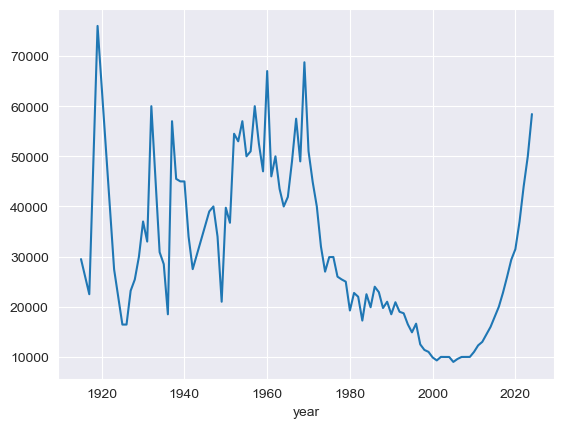

In [11]:
#Посмотрим на распределение цен по годамм

year_target_dist = df.groupby("year").median(numeric_only=True).sort_values("price", ascending=False)["price"]
sns.lineplot(x=year_target_dist.index, y=year_target_dist.values)

<Axes: xlabel='year'>

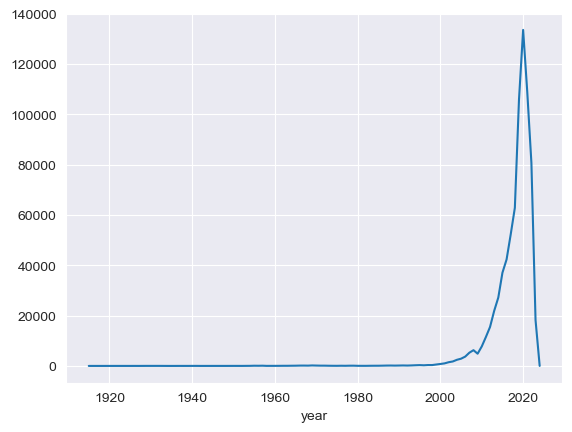

In [15]:
#Посмотрим на количесво автомобилей за каждый год
year_dist = df.groupby("year")["price"].count()
year_dist
sns.lineplot(x=year_dist.index, y=year_dist.values)

In [21]:
#Посмотрим на кол-во автомобилей до 2000-го
(df["year"] < 2000).sum()

np.int64(5877)

In [28]:
#рассмотрим корреляцию всех автомобилей, и только новых(y2000+)
modern_cars = df[df["year"] >= 2000]

print(f"All cars corr: {df["price"].corr(df["year"])}")
print(f"New cars corr^ {modern_cars["price"].corr(modern_cars["year"])}")

All cars corr: 0.29348113362294787
New cars corr^ 0.44641687528731266


<Axes: xlabel='year'>

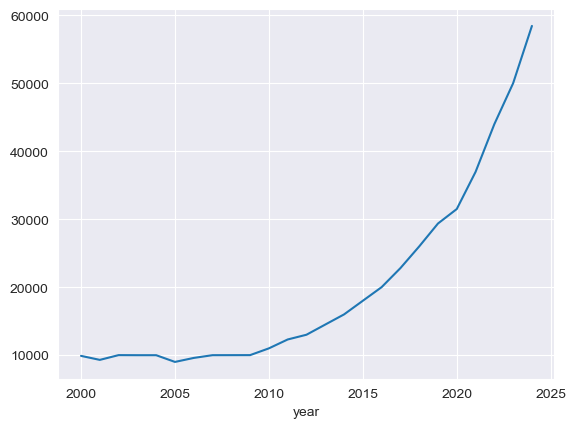

In [29]:
#Рассмотрим распределение цен новых автомоилей
modern_target_year_dist = modern_cars.groupby("year").median(numeric_only=True).sort_values("price", ascending=False)["price"]
sns.lineplot(x=modern_target_year_dist.index, y=modern_target_year_dist.values)

In [59]:
#С помощью градиентного спуска будем искать коэфициент, при котором нормализированное значение будет иметь максимальную корреляцию

def maximize_corr(df, col, target, power = 1, step = 0.1):
    col_min = df[col].min()
    col_max = df[col].max()

    normalized = (df[col] - col_min) / (col_max - col_min)

    c = abs(normalized.pow(power).corr(df[target]))

    while step > 0.01:
        temp_mileage = normalized.pow(power - step)
        cl = abs(temp_mileage.corr(df[target]))

        temp_mileage = normalized.pow(power + step)
        cr = abs(temp_mileage.corr(df[target]))

        if c > cl and c > cr:
            break
        if cl > cr:
            power = power - step
            c = cl
        else:
            power = power + step
            c = cr
        step = step * 0.99


    return normalized.pow(power), power, c


Optimal power: year^(4.764746051087997)
Correlation: 0.4984473184371234


<Axes: xlabel='year_norm'>

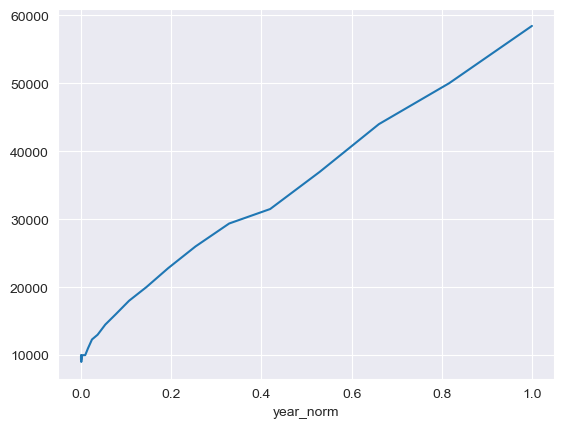

In [61]:
modern_cars.loc[:,"year_norm"], yn_pow, yn_corr = maximize_corr(modern_cars, "year", "price")
print(f"Optimal power: year^({yn_pow})\nCorrelation: {yn_corr}")
modern_target_year_norm_dist = modern_cars.groupby("year_norm").median(numeric_only=True).sort_values("price", ascending=False)["price"]
sns.lineplot(x=modern_target_year_norm_dist.index, y=modern_target_year_norm_dist.values)

In [ ]:
#Итого: Год будем клэмпить от 2000-го до 2024-го, и возводить нормализиованное число в степень 4.764746051087997

<Axes: xlabel='mileage', ylabel='price'>

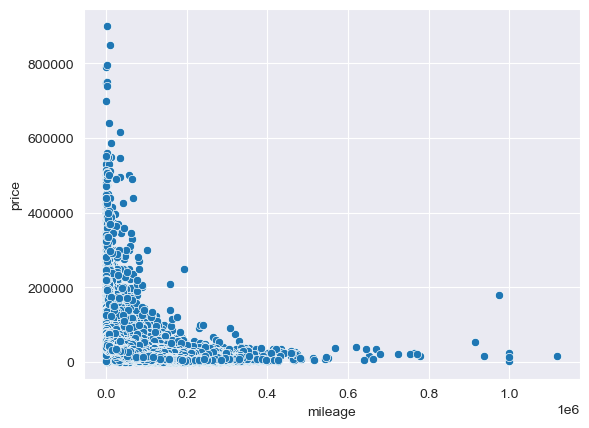

In [62]:
#Смотрим зависимость цены от миль
dummy = df.copy(deep=True)
#dummy = dummy[dummy["mileage"] < 20000]

sns.scatterplot(x=dummy.mileage, y=dummy.price)
#mile_dist

In [63]:
#Посмотрим сколько нанов
df["mileage"].isna().sum()


np.int64(505)

In [64]:
#Посмотрим сколько значений выше 800.000
df[df["mileage"] > 800000]

,manufacturer,model,year,mileage,engine,transmission,drivetrain,fuel_type,mpg,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,seller_name,seller_rating,driver_rating,driver_reviews_num,price_drop,price
76422,Buick,Century Custom,1998,999999.0,3.1L V-6 engine with 160HP,Automatic,Front-wheel Drive,Gasoline,20-27,Maroon,Bordeaux Red,0.0,0.0,1.0,Key Lime Automotive LLC,NaN,4.1,11.0,NaN,1995.0
319941,Honda,Civic LX,2013,938032.0,1.8L I4 16V MPFI SOHC,5-Speed Automatic,Front-wheel Drive,Gasoline,28-39,Dyno Blue Pearl,Black,0.0,0.0,1.0,Lithia Ford of Roseburg,3.9,4.6,287.0,872.0,14816.0
494409,Lincoln,Continental,1967,999999.0,V8,Automatic,NaN,Gasoline,NaN,Gold,Black,0.0,1.0,1.0,GR Auto Gallery,3.2,NaN,0.0,4000.0,22900.0
511961,Mercedes-Benz,GLK-Class GLK 350,2011,999999.0,3.5L V6 24V MPFI DOHC,7-Speed Automatic,Rear-wheel Drive,Gasoline,16-23,Black,NaN,1.0,0.0,1.0,Duluth Auto Exchange,NaN,4.5,32.0,NaN,13995.0
522994,Mercedes-Benz,E-Class E 350 4MATIC,2021,915383.0,2.0L I4 16V GDI DOHC Turbo,9-Speed Automatic,All-wheel Drive,Gasoline,22-30,Polar White,Macchiato Beige,0.0,0.0,0.0,Mercedes-Benz of Wesley Chapel,4.5,4.7,7.0,500.0,53539.0
617503,Porsche,356 A,1959,974302.0,NaN,4-Speed Manual,NaN,NaN,NaN,Green,Tan,0.0,NaN,NaN,European Collectibles,NaN,NaN,0.0,5000.0,179500.0
756847,Volvo,XC70 3.2L,2010,1119067.0,Gas I6 3.2L/195,Automatic,All-wheel Drive,Gasoline,16-22,Black,Beige,0.0,0.0,1.0,Walser Toyota,3.1,4.3,17.0,NaN,16997.0


<Axes: xlabel='mileage_norm', ylabel='price'>

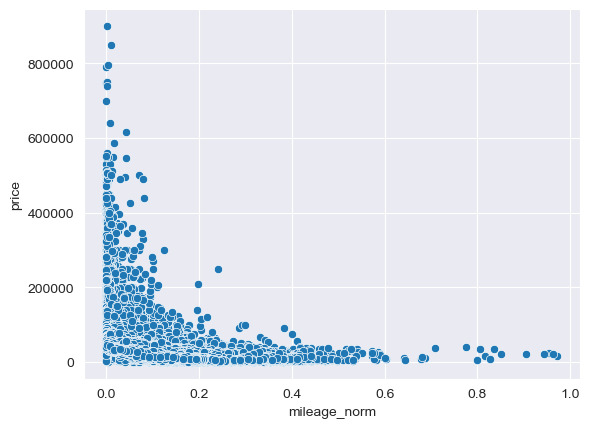

In [65]:
#Их немного, удалим, и нормализируем (0...800к) -> (0..1)
dummy["mileage"] = dummy[dummy["mileage"] < 800000]["mileage"]
dummy = dummy[~dummy["mileage"].isna()]
dummy["mileage_norm"] = dummy["mileage"] / 800000.0
sns.scatterplot(x=dummy.mileage_norm, y=dummy.price)

In [66]:
#Посмотрим корреляцию
dummy["mileage_norm"].corr(dummy["price"])

np.float64(-0.4754992130411434)

Optimal power: mileage^(0.3206534790699)
Correlation: 0.527472177001288


<Axes: xlabel='mileage_norm', ylabel='price'>

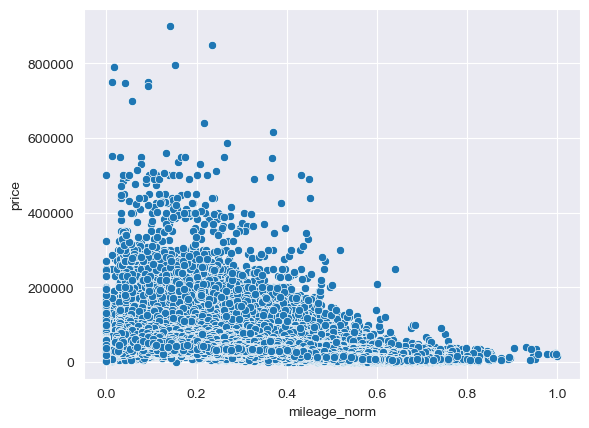

In [70]:
#С помощью градиентного спуска найдем степень от 0 до 1 при которой корреляция максимальна
dummy.loc[:,"mileage_norm"], mn_pow, mn_corr = maximize_corr(dummy, "mileage", "price")
print(f"Optimal power: mileage^({mn_pow})\nCorrelation: {mn_corr}")
sns.scatterplot(x=dummy.mileage_norm, y=dummy.price)


<Axes: xlabel='mileage_pow', ylabel='price'>

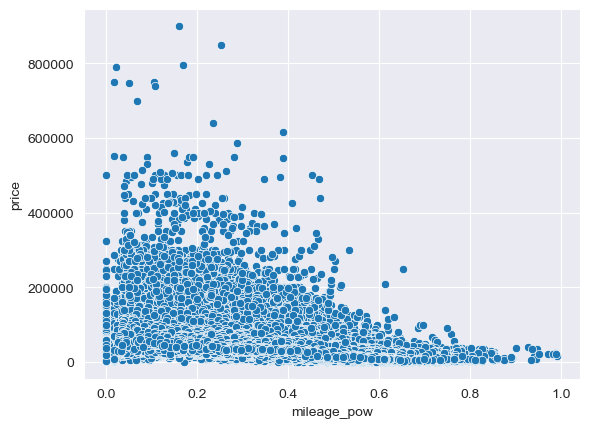

In [15]:
#Внимание на экран
dummy["mileage_pow"] = dummy["mileage_norm"].pow(0.301)
sns.scatterplot(x=dummy.mileage_pow, y=dummy.price)

In [16]:
#Посмотрим на возможные трансмиссии
print(df["transmission"].value_counts().head(50))
df.shape

transmission
6-Speed Automatic                                     148595
8-Speed Automatic                                     139570
Automatic CVT                                         108624
Automatic                                              97119
9-Speed Automatic                                      61189
10-Speed Automatic                                     40111
5-Speed Automatic                                      23129
7-Speed Automatic                                      19037
7-Speed Automatic with Auto-Shift                      15342
6-Speed Manual                                         13863
1-Speed Automatic                                      13461
4-Speed Automatic                                      12097
6-Speed Automatic with Auto-Shift                       6155
8-Speed Automatic with Auto-Shift                       5027
Manual                                                  3970
5-Speed Manual                                          3508
A/T        

(762063, 20)

In [17]:
#Проверим у скольки из них прорисано количество скоростей
dummy["dt_spd_cnt"] = dummy["transmission"].str.lower()
dummy["dt_spd_cnt"] = dummy["dt_spd_cnt"].str.extract(r"(\d+)[ -]sp\w*d")
dummy["dt_spd_cnt"].isna().value_counts()

dt_spd_cnt
False    524912
True     236639
Name: count, dtype: int64

In [18]:
#Хрень, удаляем
dummy.drop(columns=["dt_spd_cnt"], inplace=True)

In [19]:
#Попробуем разделить на 5 категории:
#   1. CVT - (CVT, Variable, Automatic CVT)
#   2. AT - (Auto, Automatic, AT, A/T
#   3. MT - (Manual, MT, M/T)
#   4. DCT - (DCT, dual clutch, Dual Shift)
#   5. Unknown

In [20]:
def get_trans_type(s):
    s = str(s).lower()
    if re.match(r".*cvt", s) or re.match(r".*variable.*", s) or re.match(r".*ivt.*", s):
        return "CVT"
    elif re.match(r".*a.?t", s):
        return "AT"
    elif re.match(r".*man", s) or re.match(r".*m.?t", s):
        return "MT"
    elif re.match(r".*DCT", s) or re.match(r".*dual", s):
        return "DCT"
    return "Unknown"

dummy["tm_type"] = dummy["transmission"].apply(get_trans_type)
dummy

,manufacturer,model,year,mileage,engine,transmission,drivetrain,fuel_type,mpg,exterior_color,...,personal_use_only,seller_name,seller_rating,driver_rating,driver_reviews_num,price_drop,price,mileage_norm,mileage_pow,tm_type
0,Acura,ILX Hybrid 1.5L,2013,92945.0,"1.5L I-4 i-VTEC variable valve control, engine...",Automatic,Front-wheel Drive,Gasoline,39-38,Black,...,0.0,Iconic Coach,NaN,4.4,12.0,300.0,13988.0,0.116181,0.523126,AT
1,Acura,ILX Hybrid 1.5L,2013,47645.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Gray,...,1.0,Kars Today,NaN,4.4,12.0,NaN,17995.0,0.059556,0.427812,CVT
2,Acura,ILX Hybrid 1.5L,2013,53422.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Bellanova White Pearl,...,1.0,Weiss Toyota of South County,4.3,4.4,12.0,500.0,17000.0,0.066778,0.442806,CVT
3,Acura,ILX Hybrid 1.5L,2013,117598.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Polished Metal Metallic,...,1.0,Apple Tree Acura,NaN,4.4,12.0,675.0,14958.0,0.146998,0.561514,CVT
4,Acura,ILX Hybrid 1.5L,2013,114865.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,NaN,...,1.0,Herb Connolly Chevrolet,3.7,4.4,12.0,300.0,14498.0,0.143581,0.557553,CVT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762086,Volvo,S60 B5 Momentum,2022,22877.0,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,All-wheel Drive,Gasoline,25-33,Bright Silver Metallic,...,0.0,Volvo Cars Danbury,4.2,4.2,2.0,250.0,34798.0,0.028596,0.343043,AT
762087,Volvo,S60 T5,2012,72900.0,250.0HP 2.5L 5 Cylinder Engine Gasoline Fuel,A/T,Front-wheel Drive,Gasoline,NaN,Red,...,NaN,NaN,NaN,4.5,101.0,NaN,12500.0,0.091125,0.486240,AT
762088,Volvo,S60 T5,2014,92000.0,2.5L I5 20V MPFI DOHC Turbo,6-Speed Automatic,Front-wheel Drive,Gasoline,21-30,Ice White,...,1.0,Dapper Car Sales,NaN,4.8,36.0,300.0,12299.0,0.115000,0.521519,AT
762089,Volvo,S60 T5 Platinum,2013,132000.0,2.5L I5 20V MPFI DOHC Turbo,6-Speed Automatic,All-wheel Drive,Gasoline,20-29,Ice White,...,0.0,Legend Auto Sales Inc.,4.6,4.7,62.0,1000.0,8995.0,0.165000,0.581383,AT


In [21]:
#Посмотрим сколько чего и как
dummy["tm_type"].value_counts()

tm_type
AT         604964
CVT        118738
MT          23845
Unknown     12983
DCT          1021
Name: count, dtype: int64

In [22]:
#Сравним число неизвестных с числом нулёмых
dummy["transmission"].isna().value_counts()

transmission
False    751657
True       9894
Name: count, dtype: int64

In [23]:
#Посмотрим на представителей неизвестных
dummy[dummy["tm_type"] == "Unknown"]["transmission"].value_counts()

transmission
6-Speed                                               893
8-Speed                                               409
A                                                     294
5-Speed                                               217
7-Speed                                               191
                                                     ... 
TRANSMISSION W DRIVER SELECTABLE MODE AND SEQUENTI      1
4L60E W/ Shift Kit                                      1
4 cylinder                                              1
1-SPEED G                                               1
8-SPEED A                                               1
Name: count, Length: 119, dtype: int64

In [24]:
#Забьем на них и сотрём))))
dummy = dummy.drop(dummy[dummy["tm_type"] == "Unknown"].index)
dummy["tm_type"].value_counts()

tm_type
AT     604964
CVT    118738
MT      23845
DCT      1021
Name: count, dtype: int64

In [25]:
#Расмотрим поле drivetrain

df["drivetrain"] = df["drivetrain"].str.lower()
df["drivetrain"].value_counts()

C:\Users\galya\AppData\Local\Temp\ipykernel_7124\3539029674.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["drivetrain"] = df["drivetrain"].str.lower()


drivetrain
front-wheel drive                                              241531
all-wheel drive                                                230334
four-wheel drive                                               157125
rear-wheel drive                                                97456
fwd                                                              6450
awd                                                              3586
4wd                                                              1923
rwd                                                              1758
unknown                                                           105
front-wheel drive with limited-slip differential                   44
four-wheel drive with locking and limited-slip differential        42
all-wheel drive with locking and limited-slip differential         33
four wheel drive                                                   22
all-wheel drive with locking differential                          20
front whe

In [26]:
#Разделим на 4 категории:
#   1. fwd - (front, fwd)
#   2. rwd - (reaer, rwd)
#   3. awd - (awd, 4wd, all, four)
#   4. Unknown

def get_train_type(s):
    s = str(s).lower()
    if re.match(r".*(all|four|4wd|awd)", s):
        return "AWD"
    elif re.match(r".*(front|fwd)", s):
        return "FWD"
    elif re.match(r".*(rear|rwd)", s) or re.match(r".*m.?t", s):
        return "RWD"
    return "Unknown"

dummy["dt_type"] = dummy["drivetrain"].apply(get_train_type)
dummy

,manufacturer,model,year,mileage,engine,transmission,drivetrain,fuel_type,mpg,exterior_color,...,seller_name,seller_rating,driver_rating,driver_reviews_num,price_drop,price,mileage_norm,mileage_pow,tm_type,dt_type
0,Acura,ILX Hybrid 1.5L,2013,92945.0,"1.5L I-4 i-VTEC variable valve control, engine...",Automatic,Front-wheel Drive,Gasoline,39-38,Black,...,Iconic Coach,NaN,4.4,12.0,300.0,13988.0,0.116181,0.523126,AT,FWD
1,Acura,ILX Hybrid 1.5L,2013,47645.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Gray,...,Kars Today,NaN,4.4,12.0,NaN,17995.0,0.059556,0.427812,CVT,FWD
2,Acura,ILX Hybrid 1.5L,2013,53422.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Bellanova White Pearl,...,Weiss Toyota of South County,4.3,4.4,12.0,500.0,17000.0,0.066778,0.442806,CVT,FWD
3,Acura,ILX Hybrid 1.5L,2013,117598.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Polished Metal Metallic,...,Apple Tree Acura,NaN,4.4,12.0,675.0,14958.0,0.146998,0.561514,CVT,FWD
4,Acura,ILX Hybrid 1.5L,2013,114865.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,NaN,...,Herb Connolly Chevrolet,3.7,4.4,12.0,300.0,14498.0,0.143581,0.557553,CVT,FWD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762086,Volvo,S60 B5 Momentum,2022,22877.0,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,All-wheel Drive,Gasoline,25-33,Bright Silver Metallic,...,Volvo Cars Danbury,4.2,4.2,2.0,250.0,34798.0,0.028596,0.343043,AT,AWD
762087,Volvo,S60 T5,2012,72900.0,250.0HP 2.5L 5 Cylinder Engine Gasoline Fuel,A/T,Front-wheel Drive,Gasoline,NaN,Red,...,NaN,NaN,4.5,101.0,NaN,12500.0,0.091125,0.486240,AT,FWD
762088,Volvo,S60 T5,2014,92000.0,2.5L I5 20V MPFI DOHC Turbo,6-Speed Automatic,Front-wheel Drive,Gasoline,21-30,Ice White,...,Dapper Car Sales,NaN,4.8,36.0,300.0,12299.0,0.115000,0.521519,AT,FWD
762089,Volvo,S60 T5 Platinum,2013,132000.0,2.5L I5 20V MPFI DOHC Turbo,6-Speed Automatic,All-wheel Drive,Gasoline,20-29,Ice White,...,Legend Auto Sales Inc.,4.6,4.7,62.0,1000.0,8995.0,0.165000,0.581383,AT,AWD


In [27]:
#Посмотрим сколько неизвестных, и сколько из них изначально нулёвые
print(dummy["dt_type"].value_counts())
print(dummy["drivetrain"].isna().value_counts())

dt_type
AWD        390372
FWD        246375
RWD         97481
Unknown     14340
Name: count, dtype: int64
drivetrain
False    734339
True      14229
Name: count, dtype: int64


In [28]:
#Почти все из неизвестных наны, и реально неизвестных по пальцам пересчитать, так что удаляем))))
dummy = dummy.drop(dummy[dummy["dt_type"] == "Unknown"].index)
dummy["dt_type"].value_counts()

dt_type
AWD    390372
FWD    246375
RWD     97481
Name: count, dtype: int64

In [29]:
#Рассмотрим стобец fuel_type
dummy["fuel_type"].value_counts()

fuel_type
Gasoline                         633642
Hybrid                            28579
Diesel                            27671
E85 Flex Fuel                     18552
Electric                          15968
Flexible Fuel                       487
Plug-In Hybrid                      116
Gasoline Fuel                        66
Gasoline/Mild Electric Hybrid        52
Premium Unleaded                     47
Regular Unleaded                     38
Compressed Natural Gas               29
Diesel Fuel                           5
Hydrogen Fuel Cell                    3
Hybrid Fuel                           3
Gas/Electric Hybrid                   2
Electric Fuel System                  2
Flex Fuel Capability                  2
PHEV                                  2
Gas                                   2
Gaseous                               2
Premium (Required)                    1
Premium                               1
Natural Gas                           1
Bi-Fuel                       

In [30]:
#Разделим на категорий
#   1.Hybrid - (hybrid, PHEV, Electric Fuel
#   2.Gasoline - (Gasoline, Gas, !(Natural gas), Unleaded)
#   3.Flex Fuel - (flex, E85)
#   4.Diesel - (Diesel)
#   5.Electic - Electric
#   6.Natural Gas - Natural
#   6.Unknown

def get_fuel_type(s):
    s = str(s).lower()
    if re.match(r".*(hybrid|phev|4wd|electric fuel)", s):
        return "Hybrid"
    elif re.match(r".*(natural)", s):
        return "Natural Gas"
    elif re.match(r".*(gasoline|gas|unleaded)", s):
        return "Gasoline"
    elif re.match(r".*(flex|e85)", s):
        return "Flex Fuel"
    elif re.match(r".*(diesel)", s):
        return "Diesel"
    elif re.match(r".*(electric)", s):
        return "Electic"
    return "Unknown"

dummy["fu_type"] = dummy["fuel_type"].apply(get_fuel_type)
dummy

,manufacturer,model,year,mileage,engine,transmission,drivetrain,fuel_type,mpg,exterior_color,...,seller_rating,driver_rating,driver_reviews_num,price_drop,price,mileage_norm,mileage_pow,tm_type,dt_type,fu_type
0,Acura,ILX Hybrid 1.5L,2013,92945.0,"1.5L I-4 i-VTEC variable valve control, engine...",Automatic,Front-wheel Drive,Gasoline,39-38,Black,...,NaN,4.4,12.0,300.0,13988.0,0.116181,0.523126,AT,FWD,Gasoline
1,Acura,ILX Hybrid 1.5L,2013,47645.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Gray,...,NaN,4.4,12.0,NaN,17995.0,0.059556,0.427812,CVT,FWD,Hybrid
2,Acura,ILX Hybrid 1.5L,2013,53422.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Bellanova White Pearl,...,4.3,4.4,12.0,500.0,17000.0,0.066778,0.442806,CVT,FWD,Hybrid
3,Acura,ILX Hybrid 1.5L,2013,117598.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Polished Metal Metallic,...,NaN,4.4,12.0,675.0,14958.0,0.146998,0.561514,CVT,FWD,Hybrid
4,Acura,ILX Hybrid 1.5L,2013,114865.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,NaN,...,3.7,4.4,12.0,300.0,14498.0,0.143581,0.557553,CVT,FWD,Hybrid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762086,Volvo,S60 B5 Momentum,2022,22877.0,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,All-wheel Drive,Gasoline,25-33,Bright Silver Metallic,...,4.2,4.2,2.0,250.0,34798.0,0.028596,0.343043,AT,AWD,Gasoline
762087,Volvo,S60 T5,2012,72900.0,250.0HP 2.5L 5 Cylinder Engine Gasoline Fuel,A/T,Front-wheel Drive,Gasoline,NaN,Red,...,NaN,4.5,101.0,NaN,12500.0,0.091125,0.486240,AT,FWD,Gasoline
762088,Volvo,S60 T5,2014,92000.0,2.5L I5 20V MPFI DOHC Turbo,6-Speed Automatic,Front-wheel Drive,Gasoline,21-30,Ice White,...,NaN,4.8,36.0,300.0,12299.0,0.115000,0.521519,AT,FWD,Gasoline
762089,Volvo,S60 T5 Platinum,2013,132000.0,2.5L I5 20V MPFI DOHC Turbo,6-Speed Automatic,All-wheel Drive,Gasoline,20-29,Ice White,...,4.6,4.7,62.0,1000.0,8995.0,0.165000,0.581383,AT,AWD,Gasoline


In [31]:
#Посмотрим сколько неизвестных, и сколько нулевых изначально было
print(dummy["fu_type"].value_counts())
print(dummy["fuel_type"].isna().value_counts())

fu_type
Gasoline       633797
Hybrid          28756
Diesel          27677
Flex Fuel       19043
Electic         15968
Unknown          8957
Natural Gas        30
Name: count, dtype: int64
fuel_type
False    725278
True       8950
Name: count, dtype: int64


In [32]:
#Удаляем неизвестных, а также более не нужные колонки
dummy = dummy.drop(dummy[dummy["fu_type"] == "Unknown"].index)

dummy = dummy.drop(columns=['transmission', 'drivetrain', 'fuel_type', 'mileage', 'mileage_norm'], errors='ignore')

dummy

,manufacturer,model,year,engine,mpg,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,seller_name,seller_rating,driver_rating,driver_reviews_num,price_drop,price,mileage_pow,tm_type,dt_type,fu_type
0,Acura,ILX Hybrid 1.5L,2013,"1.5L I-4 i-VTEC variable valve control, engine...",39-38,Black,Parchment,0.0,0.0,0.0,Iconic Coach,NaN,4.4,12.0,300.0,13988.0,0.523126,AT,FWD,Gasoline
1,Acura,ILX Hybrid 1.5L,2013,1.5L I4 8V MPFI SOHC Hybrid,39-38,Gray,Ebony,1.0,1.0,1.0,Kars Today,NaN,4.4,12.0,NaN,17995.0,0.427812,CVT,FWD,Hybrid
2,Acura,ILX Hybrid 1.5L,2013,1.5L I4 8V MPFI SOHC Hybrid,39-38,Bellanova White Pearl,Ebony,0.0,1.0,1.0,Weiss Toyota of South County,4.3,4.4,12.0,500.0,17000.0,0.442806,CVT,FWD,Hybrid
3,Acura,ILX Hybrid 1.5L,2013,1.5L I4 8V MPFI SOHC Hybrid,39-38,Polished Metal Metallic,NaN,0.0,1.0,1.0,Apple Tree Acura,NaN,4.4,12.0,675.0,14958.0,0.561514,CVT,FWD,Hybrid
4,Acura,ILX Hybrid 1.5L,2013,1.5L I4 8V MPFI SOHC Hybrid,39-38,NaN,Ebony,1.0,0.0,1.0,Herb Connolly Chevrolet,3.7,4.4,12.0,300.0,14498.0,0.557553,CVT,FWD,Hybrid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762086,Volvo,S60 B5 Momentum,2022,2.0L I4 16V GDI DOHC Turbo,25-33,Bright Silver Metallic,Blond,0.0,1.0,0.0,Volvo Cars Danbury,4.2,4.2,2.0,250.0,34798.0,0.343043,AT,AWD,Gasoline
762087,Volvo,S60 T5,2012,250.0HP 2.5L 5 Cylinder Engine Gasoline Fuel,NaN,Red,Beige,NaN,NaN,NaN,NaN,NaN,4.5,101.0,NaN,12500.0,0.486240,AT,FWD,Gasoline
762088,Volvo,S60 T5,2014,2.5L I5 20V MPFI DOHC Turbo,21-30,Ice White,Soft Beige,0.0,0.0,1.0,Dapper Car Sales,NaN,4.8,36.0,300.0,12299.0,0.521519,AT,FWD,Gasoline
762089,Volvo,S60 T5 Platinum,2013,2.5L I5 20V MPFI DOHC Turbo,20-29,Ice White,Off Black,1.0,0.0,0.0,Legend Auto Sales Inc.,4.6,4.7,62.0,1000.0,8995.0,0.581383,AT,AWD,Gasoline


engine_l
2.0     147150
3.5      76236
3.6      76214
2.5      63040
2.4      44146
         ...  
4.1         14
7.2          3
39.5         2
8.2          1
1.1          1
Name: count, Length: 71, dtype: int64
engine_l
False    697873
True      27398
Name: count, dtype: int64


<Axes: xlabel='engine_l', ylabel='price'>

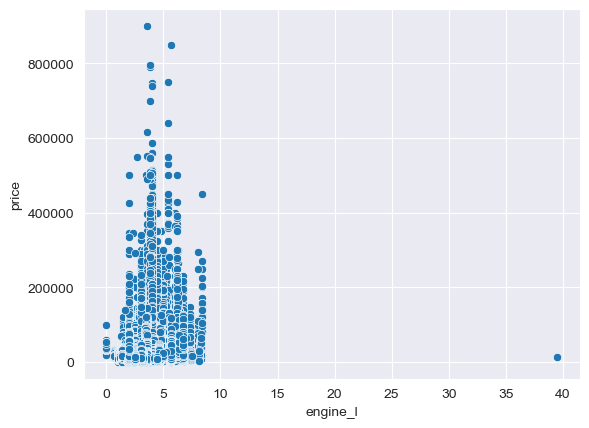

In [33]:
#Попробуем вывести лошадиные сиды из колонки engine и посмотрим скольку нуловых
dummy["engine_l"] = dummy.engine.str.extract(r"(\d+\.?\d*)\s*L").astype(float)
print(dummy["engine_l"].value_counts())
print(dummy["engine_l"].isna().value_counts())
sns.scatterplot(x=dummy["engine_l"], y=dummy["price"])

In [34]:
#Посмотрим что за зверь с 39 литрами
dummy[dummy["engine_l"] > 38]

,manufacturer,model,year,engine,mpg,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,...,seller_rating,driver_rating,driver_reviews_num,price_drop,price,mileage_pow,tm_type,dt_type,fu_type,engine_l
63469,BMW,i3 Base w/Range Extender,2014,39.5L 170.0hp,NaN,White,Gray,0.0,0.0,0.0,...,NaN,4.8,44.0,NaN,14499.0,0.364427,AT,RWD,Electic,39.5
63544,BMW,i3 Base w/Range Extender,2014,39.5L 170.0hp,NaN,Orange,White,1.0,0.0,1.0,...,NaN,4.8,44.0,NaN,12500.0,0.459477,AT,RWD,Electic,39.5


<Axes: xlabel='engine_l', ylabel='price'>

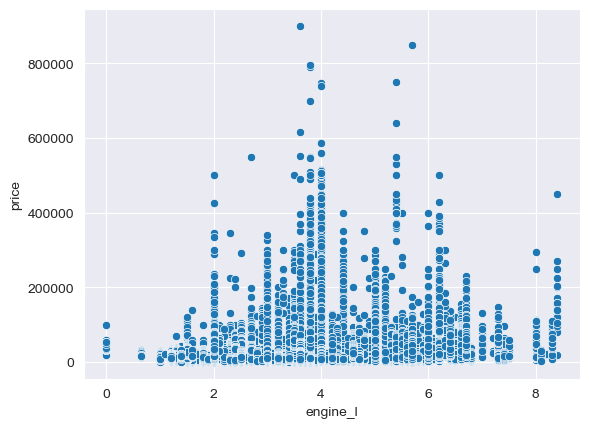

In [35]:
#После гуглина оказывается что у зверя всего 0.6 литров движок. Удаляем.
dummy.drop(dummy[dummy["engine_l"] > 38].index, inplace=True)
sns.scatterplot(x=dummy["engine_l"], y=dummy["price"])

In [36]:
# Посмотрим на тачки без указанного литража
dummy[dummy["engine_l"].isna()]

,manufacturer,model,year,engine,mpg,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,...,seller_rating,driver_rating,driver_reviews_num,price_drop,price,mileage_pow,tm_type,dt_type,fu_type,engine_l
39,Acura,NSX Sport,1991,NaN,0-0,Red,NaN,0.0,0.0,0.0,...,4.8,4.7,3.0,1460.0,92577.0,0.455777,MT,RWD,Gasoline,NaN
2533,Acura,RDX Base,2018,V6 Cylinder Engine,19-27,SILVER,GRAY,1.0,1.0,1.0,...,1.4,4.8,94.0,NaN,24995.0,0.388208,AT,AWD,Gasoline,NaN
3462,Acura,RDX A-Spec Package,2022,4 Cylinder Engine,21-26,Majestic Black Pearl,Ebony,0.0,1.0,0.0,...,4.3,4.8,2.0,NaN,49495.0,0.232442,AT,AWD,Gasoline,NaN
4262,Acura,RDX Advance Package,2022,4 Cylinder Engine,21-27,Black,Espresso,0.0,1.0,0.0,...,NaN,4.8,2.0,221.0,49729.0,0.235049,AT,AWD,Gasoline,NaN
5285,Acura,TSX Technology,2012,4 Cylinder Engine,22-31,Silver,Black,NaN,NaN,NaN,...,4.4,4.7,51.0,1000.0,11995.0,0.587582,AT,FWD,Gasoline,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
761983,Volvo,S60 T6 Momentum,2020,I-4 cyl,NaN,Crystal White Pearl,Charcoal,1.0,1.0,0.0,...,4.3,4.9,24.0,131.0,30567.0,0.376804,AT,AWD,Gasoline,NaN
761992,Volvo,S60 Momentum,2020,I-4 cyl,NaN,Pine Grey,NaN,1.0,1.0,0.0,...,3.4,4.9,24.0,496.0,31499.0,0.338873,AT,AWD,Gasoline,NaN
762031,Volvo,S60 T5 Dynamic,2018,4 Cylinder Engine,22-33,Onyx Black Metallic,NaN,1.0,0.0,1.0,...,NaN,4.8,14.0,NaN,22367.0,0.411886,AT,AWD,Gasoline,NaN
762075,Volvo,S60 Momentum,2020,4 Cylinder Engine,NaN,Osmium Grey,Blond,0.0,1.0,1.0,...,NaN,4.9,24.0,200.0,26800.0,0.440641,AT,FWD,Gasoline,NaN


In [37]:
#Вроде ниче не упустили, лишних удаляем :(
dummy.drop(dummy[dummy["engine_l"].isna()].index, inplace=True)
dummy

,manufacturer,model,year,engine,mpg,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,...,seller_rating,driver_rating,driver_reviews_num,price_drop,price,mileage_pow,tm_type,dt_type,fu_type,engine_l
0,Acura,ILX Hybrid 1.5L,2013,"1.5L I-4 i-VTEC variable valve control, engine...",39-38,Black,Parchment,0.0,0.0,0.0,...,NaN,4.4,12.0,300.0,13988.0,0.523126,AT,FWD,Gasoline,1.5
1,Acura,ILX Hybrid 1.5L,2013,1.5L I4 8V MPFI SOHC Hybrid,39-38,Gray,Ebony,1.0,1.0,1.0,...,NaN,4.4,12.0,NaN,17995.0,0.427812,CVT,FWD,Hybrid,1.5
2,Acura,ILX Hybrid 1.5L,2013,1.5L I4 8V MPFI SOHC Hybrid,39-38,Bellanova White Pearl,Ebony,0.0,1.0,1.0,...,4.3,4.4,12.0,500.0,17000.0,0.442806,CVT,FWD,Hybrid,1.5
3,Acura,ILX Hybrid 1.5L,2013,1.5L I4 8V MPFI SOHC Hybrid,39-38,Polished Metal Metallic,NaN,0.0,1.0,1.0,...,NaN,4.4,12.0,675.0,14958.0,0.561514,CVT,FWD,Hybrid,1.5
4,Acura,ILX Hybrid 1.5L,2013,1.5L I4 8V MPFI SOHC Hybrid,39-38,NaN,Ebony,1.0,0.0,1.0,...,3.7,4.4,12.0,300.0,14498.0,0.557553,CVT,FWD,Hybrid,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762086,Volvo,S60 B5 Momentum,2022,2.0L I4 16V GDI DOHC Turbo,25-33,Bright Silver Metallic,Blond,0.0,1.0,0.0,...,4.2,4.2,2.0,250.0,34798.0,0.343043,AT,AWD,Gasoline,2.0
762087,Volvo,S60 T5,2012,250.0HP 2.5L 5 Cylinder Engine Gasoline Fuel,NaN,Red,Beige,NaN,NaN,NaN,...,NaN,4.5,101.0,NaN,12500.0,0.486240,AT,FWD,Gasoline,2.5
762088,Volvo,S60 T5,2014,2.5L I5 20V MPFI DOHC Turbo,21-30,Ice White,Soft Beige,0.0,0.0,1.0,...,NaN,4.8,36.0,300.0,12299.0,0.521519,AT,FWD,Gasoline,2.5
762089,Volvo,S60 T5 Platinum,2013,2.5L I5 20V MPFI DOHC Turbo,20-29,Ice White,Off Black,1.0,0.0,0.0,...,4.6,4.7,62.0,1000.0,8995.0,0.581383,AT,AWD,Gasoline,2.5


In [38]:
#Расммотрим колонку MPG. Расмотрим значения не формата число-число
dummy[~dummy.mpg.str.match(r"\d+-\d+").astype(bool)]["mpg"].value_counts()

mpg
22    1120
0      293
18     201
21     169
24     120
19     109
16     100
25      90
20      74
14      70
13      48
23      42
17      32
27      27
29      22
15      16
26      11
35       8
12       8
11       7
30       6
34       6
33       5
31       5
28       4
43       4
37       2
10       1
51       1
Name: count, dtype: int64

In [39]:
#Разделим mpg а mpg_l и mpg_r. Если будем встречать единственное число - пишем в обе стороны
#Нуевые значения потом заменим на медианы двух колонок

def split_mpg(s):
    left = None
    right = None
    if s:
        s = str(s).lower()
        split_res = s.split("-")
        if len(split_res) == 2:
            left, right = split_res
        elif len(split_res) == 1:
            left, right = split_res[0], split_res[0]
        left = float(left)
        right = float(right)
    return pd.Series([left, right])

dummy[["mpg_l", "mpg_r"]] = dummy["mpg"].apply(split_mpg)

In [40]:
#Посмотрим сколько нуллов в каждой колоке
print(dummy["mpg_l"].isna().value_counts())
print(dummy["mpg_r"].isna().value_counts())

mpg_l
False    602661
True      95210
Name: count, dtype: int64
mpg_r
False    602661
True      95210
Name: count, dtype: int64


In [41]:
#Сравним с кол-вом нуллов в mpg
dummy["mpg"].isna().value_counts()

mpg
False    602661
True      95210
Name: count, dtype: int64

In [42]:
print(dummy["mpg_l"].median())
print(dummy["mpg_r"].median())

dummy["mpg_l"] = dummy["mpg_l"].fillna(dummy["mpg_l"].median())
dummy["mpg_r"] = dummy["mpg_r"].fillna(dummy["mpg_r"].median())
dummy

21.0
28.0


,manufacturer,model,year,engine,mpg,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,...,driver_reviews_num,price_drop,price,mileage_pow,tm_type,dt_type,fu_type,engine_l,mpg_l,mpg_r
0,Acura,ILX Hybrid 1.5L,2013,"1.5L I-4 i-VTEC variable valve control, engine...",39-38,Black,Parchment,0.0,0.0,0.0,...,12.0,300.0,13988.0,0.523126,AT,FWD,Gasoline,1.5,39.0,38.0
1,Acura,ILX Hybrid 1.5L,2013,1.5L I4 8V MPFI SOHC Hybrid,39-38,Gray,Ebony,1.0,1.0,1.0,...,12.0,NaN,17995.0,0.427812,CVT,FWD,Hybrid,1.5,39.0,38.0
2,Acura,ILX Hybrid 1.5L,2013,1.5L I4 8V MPFI SOHC Hybrid,39-38,Bellanova White Pearl,Ebony,0.0,1.0,1.0,...,12.0,500.0,17000.0,0.442806,CVT,FWD,Hybrid,1.5,39.0,38.0
3,Acura,ILX Hybrid 1.5L,2013,1.5L I4 8V MPFI SOHC Hybrid,39-38,Polished Metal Metallic,NaN,0.0,1.0,1.0,...,12.0,675.0,14958.0,0.561514,CVT,FWD,Hybrid,1.5,39.0,38.0
4,Acura,ILX Hybrid 1.5L,2013,1.5L I4 8V MPFI SOHC Hybrid,39-38,NaN,Ebony,1.0,0.0,1.0,...,12.0,300.0,14498.0,0.557553,CVT,FWD,Hybrid,1.5,39.0,38.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762086,Volvo,S60 B5 Momentum,2022,2.0L I4 16V GDI DOHC Turbo,25-33,Bright Silver Metallic,Blond,0.0,1.0,0.0,...,2.0,250.0,34798.0,0.343043,AT,AWD,Gasoline,2.0,25.0,33.0
762087,Volvo,S60 T5,2012,250.0HP 2.5L 5 Cylinder Engine Gasoline Fuel,NaN,Red,Beige,NaN,NaN,NaN,...,101.0,NaN,12500.0,0.486240,AT,FWD,Gasoline,2.5,21.0,28.0
762088,Volvo,S60 T5,2014,2.5L I5 20V MPFI DOHC Turbo,21-30,Ice White,Soft Beige,0.0,0.0,1.0,...,36.0,300.0,12299.0,0.521519,AT,FWD,Gasoline,2.5,21.0,30.0
762089,Volvo,S60 T5 Platinum,2013,2.5L I5 20V MPFI DOHC Turbo,20-29,Ice White,Off Black,1.0,0.0,0.0,...,62.0,1000.0,8995.0,0.581383,AT,AWD,Gasoline,2.5,20.0,29.0


In [43]:
dummy["exterior_color"].value_counts().head(50)

exterior_color
Black                                 55579
White                                 46585
Gray                                  28232
Silver                                23129
Summit White                          16237
Blue                                  16037
Red                                   13887
Bright White Clearcoat                13470
Oxford White                           7563
Gun Metallic                           6869
Granite Crystal Clearcoat Metallic     6373
Alpine White                           4926
Billet Silver Metallic Clearcoat       4805
Polar White                            4717
Silver Ice Metallic                    4459
Satin Steel Metallic                   4387
Onyx Black                             4366
Black Sapphire Metallic                4155
Pure White                             4088
Diamond Black                          3967
Crystal White Pearl                    3927
Black Clearcoat                        3834
Shadow Black     

In [44]:
#Сделаем замену цветов по ключевым словам
desc = [['black', ['black', 'noir', 'onyx', 'caviar']],
              ['white', ['white', 'blanc', 'pearl', 'whiite', 'fresh powder']],
              ['silver', ['silver']],
              ['gray', ['gray', 'grey', 'charcoal', 'graphite', 'slate']],
              ['red', ['red', 'burgundy', 'maroon', 'cherry', 'crimson', 'scarlet ember']],
              ['blue', ['blue', 'navy', 'indigo', 'lunar', 'area 51']],
              ['green', ['green', 'emerald', 'olive']],
              ['brown', ['brown', 'tan', 'espresso', 'bronze', 'chocolate']],
              ['yellow', ['yellow', 'gold', 'champagne']],
              ['orange', ['orange', 'copper']],
              ['purple', ['purple', 'violet']],
              ['metal', ['metal', 'steel', 'platinum', 'pewter', 'magnetic', 'billet']],
              ['beige', ['beige', 'birch']],
              ]

def simplify_color(s):
    s = str(s).lower()
    res = 'other'

    for pal in desc:
        for col in pal[1]:
            if col in s:
                res = pal[0]
                break
        if res != 'other':
            break
    return res

dummy["ext_col_simp"] = dummy["exterior_color"].apply(simplify_color)
dummy[(dummy["ext_col_simp"] == 'other') & (~dummy["exterior_color"].isna())]["exterior_color"].value_counts().head(50)
#dummy[(dummy["ext_col_simp"] == 'other')]["exterior_color"]

exterior_color
Nightfall Mica              418
Stormy Sea                  407
Triple Nickel Clearcoat     335
Go Mango!                   295
Smoke Show                  273
Frostbite                   267
Cement                      258
CELESTITE                   252
Smoke                       240
Rhino Clearcoat             237
Dark Moss                   235
Mocha                       232
Mocha Almond                226
Chalk                       213
Galactic Aqua               212
Granite Clearcoat           193
Deep                        184
Moon Dust                   162
Cactus                      161
Ice                         153
Hellraisin                  152
Ooh La La Rouge Mica        149
Deep Cerulean               147
Night Armor                 145
Sunset Drift Chromaflair    138
Smoky Granite Mica          132
Ebony                       131
Sinamon Stick               129
Iridium                     126
Anvil                       121
Designo                  

In [45]:
print(dummy["ext_col_simp"].value_counts())
print(dummy["exterior_color"].isna().value_counts())

ext_col_simp
white     195005
black     149214
silver     84003
gray       79435
blue       52689
red        48310
metal      44972
other      22875
brown       6751
green       5892
yellow      4063
orange      3575
beige        718
purple       369
Name: count, dtype: int64
exterior_color
False    689875
True       7996
Name: count, dtype: int64


In [46]:
#пробуем применить тот же метод для интерьера
dummy["int_col_simp"] = dummy["interior_color"].apply(simplify_color)
print(dummy["int_col_simp"].value_counts())
print(dummy["interior_color"].isna().value_counts())


int_col_simp
black     368554
other     153945
gray      108671
beige      25587
brown      22607
red         8359
metal       3847
white       2936
blue        1969
silver       739
orange       319
yellow       229
green        106
purple         3
Name: count, dtype: int64
interior_color
False    649477
True      48394
Name: count, dtype: int64


In [47]:
#меняем дескриптор
desc = [['black', ['black', 'noir', 'onyx', 'caviar', 'ebony', 'dark']],
              ['white', ['white', 'blanc', 'pearl', 'whiite', 'fresh powder', 'light']],
              ['silver', ['silver']],
              ['gray', ['gray', 'grey', 'charcoal', 'graphite', 'slate', 'ash', 'stone', 'cement']],
              ['red', ['red', 'burgundy', 'maroon', 'cherry', 'crimson', 'scarlet ember', 'cognac']],
              ['blue', ['blue', 'navy', 'indigo', 'lunar', 'area 51']],
              ['green', ['green', 'emerald', 'olive']],
              ['brown', ['brown', 'tan', 'espresso', 'bronze', 'chocolate', 'mocha', 'cocoa']],
              ['yellow', ['yellow', 'gold', 'champagne']],
              ['orange', ['orange', 'copper', 'sand', 'dune']],
              ['purple', ['purple', 'violet']],
              ['metal', ['metal', 'steel', 'platinum', 'pewter', 'magnetic', 'billet']],
              ['beige', ['beige', 'birch', 'ivory', 'parchment', 'wheat', 'sandstone', 'cappuccino', 'almond', 'blond', 'taupe', 'cream']],
              ]

dummy["int_col_simp"] = dummy["interior_color"].apply(simplify_color)
print(dummy["int_col_simp"].value_counts())
print(dummy["interior_color"].isna().value_counts())

int_col_simp
black     421642
gray      108591
other      70797
beige      40201
brown      24950
white      11985
red        10435
metal       3484
orange      3006
blue        1746
silver       723
yellow       222
green         86
purple         3
Name: count, dtype: int64
interior_color
False    649477
True      48394
Name: count, dtype: int64


In [48]:
#Смотрим на ненулевых представителей other
dummy[(dummy["int_col_simp"] == 'other') & (~dummy['interior_color'].isna())]["interior_color"].value_counts()

interior_color
Sport                     1599
Shale                     1032
Java                       790
Camel                      753
Cirrus                     631
                          ... 
Fa20                         1
Le Hybrid                    1
Gy                           1
Bk                           1
Nappa Lthr Sport Seats       1
Name: count, Length: 439, dtype: int64

In [49]:
#Давайте рассмотрим сколько неизвестных получилось там и сям
print(f"Exterior color others: {dummy[(dummy['ext_col_simp'] == 'other')]['int_col_simp'].count()}\n\
Interior color others: {dummy[(dummy['int_col_simp'] == 'other')]['int_col_simp'].count()}")

print(f"Exterior color nans: {dummy['exterior_color'].isna().value_counts()}\n\
Interior color nans: {dummy['interior_color'].isna().value_counts()}")

Exterior color others: 22875
Interior color others: 70797
Exterior color nans: exterior_color
False    689875
True       7996
Name: count, dtype: int64
Interior color nans: interior_color
False    649477
True      48394
Name: count, dtype: int64


In [50]:
dummy.groupby("ext_col_simp")["price"].median().sort_values(ascending=False)

ext_col_simp
green     29714.0
white     28999.0
black     28500.0
other     28497.0
metal     26999.0
gray      26889.0
blue      26129.0
red       25488.0
orange    24480.0
silver    23998.0
purple    21998.0
brown     21463.0
yellow    18476.0
beige     17350.0
Name: price, dtype: float64

In [52]:
#######################################################################################
#######################################################################################
#######################################################################################
#######################################################################################
#######################################################################################
#######################################################################################
#Дальше идут только тесты разных штук

In [106]:
dummy_exp = dummy.copy(deep=True)
dummy_exp

,manufacturer,model,year,engine,mpg,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,...,price,mileage_pow,tm_type,dt_type,fu_type,engine_l,mpg_l,mpg_r,ext_col_simp,int_col_simp
0,Acura,ILX Hybrid 1.5L,2013,"1.5L I-4 i-VTEC variable valve control, engine...",39-38,Black,Parchment,0.0,0.0,0.0,...,13988.0,0.523126,AT,FWD,Gasoline,1.5,39.0,38.0,black,beige
1,Acura,ILX Hybrid 1.5L,2013,1.5L I4 8V MPFI SOHC Hybrid,39-38,Gray,Ebony,1.0,1.0,1.0,...,17995.0,0.427812,CVT,FWD,Hybrid,1.5,39.0,38.0,gray,black
2,Acura,ILX Hybrid 1.5L,2013,1.5L I4 8V MPFI SOHC Hybrid,39-38,Bellanova White Pearl,Ebony,0.0,1.0,1.0,...,17000.0,0.442806,CVT,FWD,Hybrid,1.5,39.0,38.0,white,black
3,Acura,ILX Hybrid 1.5L,2013,1.5L I4 8V MPFI SOHC Hybrid,39-38,Polished Metal Metallic,NaN,0.0,1.0,1.0,...,14958.0,0.561514,CVT,FWD,Hybrid,1.5,39.0,38.0,metal,other
4,Acura,ILX Hybrid 1.5L,2013,1.5L I4 8V MPFI SOHC Hybrid,39-38,NaN,Ebony,1.0,0.0,1.0,...,14498.0,0.557553,CVT,FWD,Hybrid,1.5,39.0,38.0,other,black
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762086,Volvo,S60 B5 Momentum,2022,2.0L I4 16V GDI DOHC Turbo,25-33,Bright Silver Metallic,Blond,0.0,1.0,0.0,...,34798.0,0.343043,AT,AWD,Gasoline,2.0,25.0,33.0,silver,beige
762087,Volvo,S60 T5,2012,250.0HP 2.5L 5 Cylinder Engine Gasoline Fuel,NaN,Red,Beige,NaN,NaN,NaN,...,12500.0,0.486240,AT,FWD,Gasoline,2.5,21.0,28.0,red,beige
762088,Volvo,S60 T5,2014,2.5L I5 20V MPFI DOHC Turbo,21-30,Ice White,Soft Beige,0.0,0.0,1.0,...,12299.0,0.521519,AT,FWD,Gasoline,2.5,21.0,30.0,white,beige
762089,Volvo,S60 T5 Platinum,2013,2.5L I5 20V MPFI DOHC Turbo,20-29,Ice White,Off Black,1.0,0.0,0.0,...,8995.0,0.581383,AT,AWD,Gasoline,2.5,20.0,29.0,white,black


In [107]:
def print_nans_counts(df):
    for col in df.columns:
        na_counts = (df[col].isna()).sum()
        if na_counts > 0:
            print(f"---------------------\nColumn: {col}")
            print(f"Type {df[col].dtype}")
            print(f"Nan count: {na_counts}")

print_nans_counts(dummy_exp)

---------------------
Column: mpg
Type object
Nan count: 95210
---------------------
Column: exterior_color
Type object
Nan count: 7996
---------------------
Column: interior_color
Type object
Nan count: 48394
---------------------
Column: accidents_or_damage
Type float64
Nan count: 21629
---------------------
Column: one_owner
Type float64
Nan count: 25966
---------------------
Column: personal_use_only
Type float64
Nan count: 21742
---------------------
Column: seller_name
Type object
Nan count: 7904
---------------------
Column: seller_rating
Type float64
Nan count: 193105
---------------------
Column: driver_rating
Type float64
Nan count: 25868
---------------------
Column: price_drop
Type float64
Nan count: 316129


In [108]:
dummy_exp.drop(columns=["model", "engine", "mpg", "exterior_color", "interior_color", "seller_name", 'price_drop'], inplace=True, errors = "ignore")
dummy_exp

,manufacturer,year,accidents_or_damage,one_owner,personal_use_only,seller_rating,driver_rating,driver_reviews_num,price,mileage_pow,tm_type,dt_type,fu_type,engine_l,mpg_l,mpg_r,ext_col_simp,int_col_simp
0,Acura,2013,0.0,0.0,0.0,NaN,4.4,12.0,13988.0,0.523126,AT,FWD,Gasoline,1.5,39.0,38.0,black,beige
1,Acura,2013,1.0,1.0,1.0,NaN,4.4,12.0,17995.0,0.427812,CVT,FWD,Hybrid,1.5,39.0,38.0,gray,black
2,Acura,2013,0.0,1.0,1.0,4.3,4.4,12.0,17000.0,0.442806,CVT,FWD,Hybrid,1.5,39.0,38.0,white,black
3,Acura,2013,0.0,1.0,1.0,NaN,4.4,12.0,14958.0,0.561514,CVT,FWD,Hybrid,1.5,39.0,38.0,metal,other
4,Acura,2013,1.0,0.0,1.0,3.7,4.4,12.0,14498.0,0.557553,CVT,FWD,Hybrid,1.5,39.0,38.0,other,black
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762086,Volvo,2022,0.0,1.0,0.0,4.2,4.2,2.0,34798.0,0.343043,AT,AWD,Gasoline,2.0,25.0,33.0,silver,beige
762087,Volvo,2012,NaN,NaN,NaN,NaN,4.5,101.0,12500.0,0.486240,AT,FWD,Gasoline,2.5,21.0,28.0,red,beige
762088,Volvo,2014,0.0,0.0,1.0,NaN,4.8,36.0,12299.0,0.521519,AT,FWD,Gasoline,2.5,21.0,30.0,white,beige
762089,Volvo,2013,1.0,0.0,0.0,4.6,4.7,62.0,8995.0,0.581383,AT,AWD,Gasoline,2.5,20.0,29.0,white,black


In [109]:
for col in ['accidents_or_damage', 'one_owner', 'personal_use_only', ]:
    dummy_exp[col] = dummy_exp[col].fillna(0)

print_nans_counts(dummy_exp)

---------------------
Column: seller_rating
Type float64
Nan count: 193105
---------------------
Column: driver_rating
Type float64
Nan count: 25868


In [110]:
dummy_exp["seller_rating"] = dummy_exp["seller_rating"].fillna(dummy_exp["seller_rating"].median())
dummy_exp["driver_rating"] = dummy_exp["driver_rating"].fillna(dummy_exp["driver_rating"].median())

print_nans_counts(dummy_exp)

In [111]:
dummy_exp["year"] = (dummy_exp["year"] - 2000) / 26
dummy_exp

,manufacturer,year,accidents_or_damage,one_owner,personal_use_only,seller_rating,driver_rating,driver_reviews_num,price,mileage_pow,tm_type,dt_type,fu_type,engine_l,mpg_l,mpg_r,ext_col_simp,int_col_simp
0,Acura,0.500000,0.0,0.0,0.0,4.5,4.4,12.0,13988.0,0.523126,AT,FWD,Gasoline,1.5,39.0,38.0,black,beige
1,Acura,0.500000,1.0,1.0,1.0,4.5,4.4,12.0,17995.0,0.427812,CVT,FWD,Hybrid,1.5,39.0,38.0,gray,black
2,Acura,0.500000,0.0,1.0,1.0,4.3,4.4,12.0,17000.0,0.442806,CVT,FWD,Hybrid,1.5,39.0,38.0,white,black
3,Acura,0.500000,0.0,1.0,1.0,4.5,4.4,12.0,14958.0,0.561514,CVT,FWD,Hybrid,1.5,39.0,38.0,metal,other
4,Acura,0.500000,1.0,0.0,1.0,3.7,4.4,12.0,14498.0,0.557553,CVT,FWD,Hybrid,1.5,39.0,38.0,other,black
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762086,Volvo,0.846154,0.0,1.0,0.0,4.2,4.2,2.0,34798.0,0.343043,AT,AWD,Gasoline,2.0,25.0,33.0,silver,beige
762087,Volvo,0.461538,0.0,0.0,0.0,4.5,4.5,101.0,12500.0,0.486240,AT,FWD,Gasoline,2.5,21.0,28.0,red,beige
762088,Volvo,0.538462,0.0,0.0,1.0,4.5,4.8,36.0,12299.0,0.521519,AT,FWD,Gasoline,2.5,21.0,30.0,white,beige
762089,Volvo,0.500000,1.0,0.0,0.0,4.6,4.7,62.0,8995.0,0.581383,AT,AWD,Gasoline,2.5,20.0,29.0,white,black


In [114]:
def kfold_target_encode(df, col, target, n_splits=5, m=20):
    global_mean = df[target].mean()
    encoded = pd.Series(np.nan, index=df.index)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_idx, val_idx in kf.split(df):
        # Считаем статистики ТОЛЬКО по train-части фолда
        train = df.iloc[train_idx]
        agg = train.groupby(col)[target].agg(['mean', 'count'])

        # Encoding со сглаживанием
        mapping = (
            (agg['count'] * agg['mean'] + m * global_mean) /
            (agg['count'] + m)
        )

        # Применяем к val-части фолда
        encoded.iloc[val_idx] = df.iloc[val_idx][col].map(mapping)

    # Новые категории (не встретились в фолде) — global_mean
    encoded.fillna(global_mean, inplace=True)
    return encoded

def target_encode_test(train, test, col, target, m=20):
    global_mean = train[target].mean()
    agg = train.groupby(col)[target].agg(['mean', 'count'])

    mapping = (
        (agg['count'] * agg['mean'] + m * global_mean) /
        (agg['count'] + m)
    )

    encoded = test[col].map(mapping).fillna(global_mean)
    return encoded

In [115]:
def target_encode_columns(df, columns,  target, n_splits=5, m=20):
    for col in columns:
        encoded = kfold_target_encode(df, col, target, n_splits=n_splits, m=m)
        df.loc[:,col + '_enc'] = encoded

def target_encode_columns_test(train, test, columns, target, m=20):
    for col in columns:
        encoded = target_encode_test(train, test, col, target, m=m)
        test.loc[:,col + '_enc'] = encoded

In [116]:
named_columns = ["manufacturer", "tm_type", "dt_type", "fu_type", "ext_col_simp", "int_col_simp"]


In [127]:
train, test = train_test_split(dummy_exp, test_size=0.2, random_state=228)

target_encode_columns(train, named_columns, "price")
target_encode_columns_test(train, test, named_columns, "price")

train.drop(columns=named_columns, inplace=True)
test.drop(columns=named_columns, inplace=True)

train.drop(columns=['ext_col_simp_enc'], inplace=True)
test.drop(columns=['ext_col_simp_enc'], inplace=True)
train.drop(columns=['int_col_simp_enc'], inplace=True)
test.drop(columns=['int_col_simp_enc'], inplace=True)

test

,year,accidents_or_damage,one_owner,personal_use_only,seller_rating,driver_rating,driver_reviews_num,price,mileage_pow,engine_l,mpg_l,mpg_r,manufacturer_enc,tm_type_enc,dt_type_enc,fu_type_enc
231910,0.807692,0.0,1.0,0.0,3.1,4.7,0.0,46995.0,0.475759,3.5,21.0,28.0,32700.685419,33149.778903,36178.321185,21019.504793
345287,0.807692,0.0,1.0,1.0,4.4,4.9,92.0,43990.0,0.406016,3.8,19.0,24.0,21318.246361,33149.778903,37004.448983,30888.534933
362789,0.038462,0.0,0.0,1.0,1.9,4.8,12.0,4988.0,0.678649,2.0,23.0,30.0,29788.192665,33149.778903,21430.156632,30888.534933
447024,0.730769,0.0,0.0,1.0,4.8,4.7,163.0,13087.0,0.539866,2.0,21.0,28.0,22105.032711,23990.029900,21430.156632,30888.534933
283565,0.730769,0.0,0.0,0.0,4.5,4.6,119.0,23000.0,0.459786,1.5,24.0,28.0,39974.165727,33149.778903,37004.448983,30888.534933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311742,0.807692,0.0,1.0,1.0,4.5,4.7,45.0,26998.0,0.330076,1.8,26.0,31.0,24596.852584,23990.029900,37004.448983,30888.534933
247303,0.730769,0.0,0.0,0.0,2.6,4.4,239.0,35576.0,0.481094,2.3,20.0,0.0,32700.685419,33149.778903,37004.448983,30888.534933
103149,0.653846,1.0,0.0,1.0,3.9,4.8,264.0,20713.0,0.546972,3.6,22.0,31.0,30994.406223,30668.431035,36178.321185,30888.534933
715084,0.384615,0.0,1.0,1.0,2.9,4.4,78.0,24772.0,0.485343,4.0,16.0,20.0,29604.171029,33149.778903,37004.448983,30888.534933


In [128]:
X_train = train.drop(columns=["price"])
X_test = test.drop(columns=["price"])

y_train = train["price"]
y_test = test["price"]

In [129]:
X_train

,year,accidents_or_damage,one_owner,personal_use_only,seller_rating,driver_rating,driver_reviews_num,mileage_pow,engine_l,mpg_l,mpg_r,manufacturer_enc,tm_type_enc,dt_type_enc,fu_type_enc
558022,0.653846,1.0,1.0,0.0,4.5,3.5,7.0,0.548364,4.0,21.0,28.0,23378.646985,33129.755737,36197.252200,30889.236189
215732,0.807692,1.0,1.0,0.0,4.9,4.5,20.0,0.368729,6.7,21.0,28.0,32671.420594,33182.675433,37017.581019,53165.895984
450521,0.807692,0.0,1.0,1.0,4.6,4.8,51.0,0.393771,1.6,27.0,35.0,22139.102626,33160.250324,21445.906182,30893.659181
365011,0.730769,1.0,1.0,1.0,4.6,4.5,57.0,0.500634,3.5,20.0,27.0,29801.919907,23976.185353,21433.359356,30902.683352
484059,0.153846,0.0,0.0,1.0,1.7,4.6,55.0,0.621713,3.3,20.0,29.0,34544.270312,33129.755737,21418.101304,30889.236189
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133190,0.769231,0.0,1.0,1.0,2.7,4.7,69.0,0.374718,3.6,21.0,27.0,31066.654412,33144.166162,36997.884908,30881.892569
631971,0.769231,0.0,1.0,1.0,3.7,4.3,48.0,0.318544,6.4,21.0,28.0,43834.156339,33129.755737,36197.252200,30889.236189
431905,0.615385,0.0,0.0,0.0,4.6,4.6,250.0,0.579685,2.4,24.0,35.0,22151.042484,33182.675433,21433.359356,30902.683352
362946,0.846154,0.0,0.0,1.0,4.7,5.0,3.0,0.308690,3.5,21.0,26.0,29798.445323,33131.970111,21427.577789,30875.247281


In [130]:
X_test

,year,accidents_or_damage,one_owner,personal_use_only,seller_rating,driver_rating,driver_reviews_num,mileage_pow,engine_l,mpg_l,mpg_r,manufacturer_enc,tm_type_enc,dt_type_enc,fu_type_enc
231910,0.807692,0.0,1.0,0.0,3.1,4.7,0.0,0.475759,3.5,21.0,28.0,32700.685419,33149.778903,36178.321185,21019.504793
345287,0.807692,0.0,1.0,1.0,4.4,4.9,92.0,0.406016,3.8,19.0,24.0,21318.246361,33149.778903,37004.448983,30888.534933
362789,0.038462,0.0,0.0,1.0,1.9,4.8,12.0,0.678649,2.0,23.0,30.0,29788.192665,33149.778903,21430.156632,30888.534933
447024,0.730769,0.0,0.0,1.0,4.8,4.7,163.0,0.539866,2.0,21.0,28.0,22105.032711,23990.029900,21430.156632,30888.534933
283565,0.730769,0.0,0.0,0.0,4.5,4.6,119.0,0.459786,1.5,24.0,28.0,39974.165727,33149.778903,37004.448983,30888.534933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311742,0.807692,0.0,1.0,1.0,4.5,4.7,45.0,0.330076,1.8,26.0,31.0,24596.852584,23990.029900,37004.448983,30888.534933
247303,0.730769,0.0,0.0,0.0,2.6,4.4,239.0,0.481094,2.3,20.0,0.0,32700.685419,33149.778903,37004.448983,30888.534933
103149,0.653846,1.0,0.0,1.0,3.9,4.8,264.0,0.546972,3.6,22.0,31.0,30994.406223,30668.431035,36178.321185,30888.534933
715084,0.384615,0.0,1.0,1.0,2.9,4.4,78.0,0.485343,4.0,16.0,20.0,29604.171029,33149.778903,37004.448983,30888.534933


In [131]:
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [141]:
X_train

array([[0.92708333, 1.        , 1.        , ..., 0.30797052, 0.73918607,
        0.20286129],
       [0.96875   , 1.        , 1.        , ..., 1.        , 0.73903461,
        0.04163054],
       [0.96875   , 0.        , 1.        , ..., 0.30810792, 0.61793244,
        0.2186233 ],
       ...,
       [0.91666667, 0.        , 0.        , ..., 0.30838826, 0.5871466 ,
        0.21892095],
       [0.97916667, 0.        , 0.        , ..., 0.30753595, 0.21369552,
        0.04118802],
       [0.94791667, 0.        , 1.        , ..., 0.30810792, 0.58772516,
        0.2186233 ]], shape=(558296, 17))

In [132]:
from sklearn.linear_model import Ridge

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [133]:
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 7427.714218501723
RMSE: 14222.85907186066
R2: 0.5712070167902481


In [134]:
cv = KFold(n_splits=5, shuffle=True, random_state=228)
cv_scores = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=-1
)

print("CV MAE:", -cv_scores["test_mae"].mean())
print("CV RMSE:", -cv_scores["test_rmse"].mean())
print("CV R2:", cv_scores["test_r2"].mean())

CV MAE: 7376.685192366375
CV RMSE: 14099.178714625747
CV R2: 0.5745524559238783


In [96]:
dummy["price"].mean()

np.float64(31627.297166668337)

<Axes: xlabel='None', ylabel='price'>

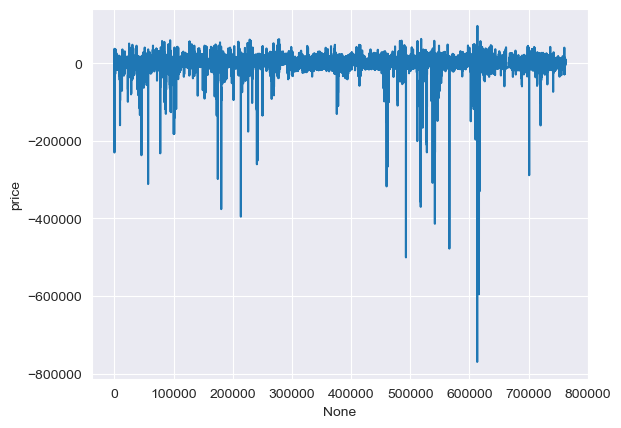

In [85]:
error = y_pred - y_test
sns.lineplot(x=error.index, y=error)

In [116]:
top_error = error[error.abs() > 10000]
dummy.iloc(top_error.index.tolist())



SyntaxError: invalid syntax (2773362585.py, line 2)

In [136]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)



Coefficients: [100594.27694908  -1833.66285487   -270.06027195    973.76480051
   2268.71234549   2479.14479624  -2612.35006411 -73060.81989512
  39195.02263649  28744.4118771  -93145.94355216  45409.12900079
   -413.13824302   1443.29045969  10724.82570359]
Intercept: -57722.19202420124


In [137]:
train.columns

Index(['year', 'accidents_or_damage', 'one_owner', 'personal_use_only',
       'seller_rating', 'driver_rating', 'driver_reviews_num', 'price',
       'mileage_pow', 'engine_l', 'mpg_l', 'mpg_r', 'manufacturer_enc',
       'tm_type_enc', 'dt_type_enc', 'fu_type_enc'],
      dtype='object')